In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', subdir, f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [99]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'Hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'Ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [121]:
hydrogenBAUDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production without electricity, steam reforming') & ~hydrogenGWPDF['Activity'].str.contains('CCS')]
hydrogenBaseBAUDF = hydrogenBAUDF[hydrogenBAUDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenBAUDF.merge(hydrogenBaseBAUDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
hydrogenMergedDF['Percentage difference'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP_base']) / hydrogenMergedDF['GWP_base']) * 100
hydrogenMergedDFImage = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('image') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDFRemind = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('remind') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenGroupedBAUDFImage = hydrogenMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedBAUDFImage = hydrogenGroupedBAUDFImage.reset_index()
hydrogenGroupedBAUDFRemind = hydrogenMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedBAUDFRemind = hydrogenGroupedBAUDFRemind.reset_index()

hydrogenSolarDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('solar')]
hydrogenBaseSolarDF = hydrogenSolarDF[hydrogenSolarDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenSolarDF.merge(hydrogenBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
hydrogenMergedDF['Percentage difference'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP_base']) / hydrogenMergedDF['GWP_base']) * 100
hydrogenMergedDFImage = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('image') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDFRemind = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('remind') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenGroupedSolarDFImage = hydrogenMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedSolarDFImage = hydrogenGroupedSolarDFImage.reset_index()
hydrogenGroupedSolarDFRemind = hydrogenMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedSolarDFRemind = hydrogenGroupedSolarDFRemind.reset_index()

hydrogenWindDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('onshore wind')]
hydrogenBaseWindDF = hydrogenWindDF[hydrogenWindDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenWindDF.merge(hydrogenBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
hydrogenMergedDF['Percentage difference'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP_base']) / hydrogenMergedDF['GWP_base']) * 100
hydrogenMergedDFImage = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('image') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDFRemind = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('remind') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenGroupedWindDFImage = hydrogenMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedWindDFImage = hydrogenGroupedWindDFImage.reset_index()
hydrogenGroupedWindDFRemind = hydrogenMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedWindDFRemind = hydrogenGroupedWindDFRemind.reset_index()

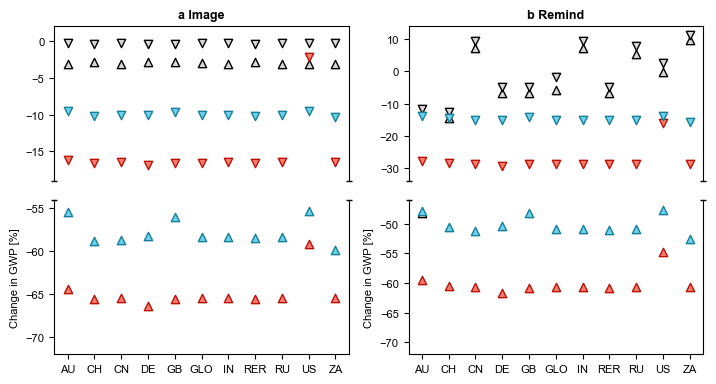

In [141]:
fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, sharex = True, figsize = (fig_length[2], fig_height*0.4), gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace = 0) 

ax1.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax1.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax1.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2)
ax1.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3)
ax1.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax1.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax1.set_ylim([-19, 2])
ax1.set_title('a Image', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax2.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax2.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax2.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2)
ax2.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3)
ax2.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax2.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax2.set_ylim([-72, -54])

ax3.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax3.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax3.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2)
ax3.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3)
ax3.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax3.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax3.set_ylim([-34, 14])
ax3.set_title('b Remind', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax4.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax4.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
ax4.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2)
ax4.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3)
ax4.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax4.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3)
ax4.set_ylim([-72, -46])

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

ax2.set_ylabel(r'Change in GWP [%]')

ax4.set_ylabel(r'Change in GWP [%]')

plotPathPNG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Hydrogen WO Elec SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Hydrogen WO Elec SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight')